# Reporting
Figures and tables for the academic publication.

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from itertools import cycle
from scipy.stats import zscore
from umap import UMAP

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)

ASSETS = os.path.join('..', 'assets')
MODELS = os.path.join(ASSETS, 'topic_models')
EMBEDS = os.path.join(ASSETS, 'embeddings')

In [11]:
# Load papers dataset
papers = pd.read_csv(os.path.join(ASSETS, 'synbio_openalex.txt'), sep='\t')

# Load topic assignments and topic names
doc_topics = pd.read_csv(os.path.join(MODELS, 'papers_doc_topics.txt'), sep='\t')
topic_names = pd.read_csv(os.path.join(MODELS, 'papers_topic_names.txt'), sep='\t')

# Merge topics into papers
papers = papers.merge(doc_topics, on='id', how='left')
papers = papers.merge(topic_names[['topic', 'global_name']], on='topic', how='left')

# Basic cleaning
papers['cited_by_count'] = pd.to_numeric(papers['cited_by_count'], errors='coerce').fillna(0).astype(int)
papers['publication_year'] = pd.to_numeric(papers['publication_year'], errors='coerce')

print(f"Papers: {len(papers):,}")
print(f"Topics: {papers['topic'].nunique()} (incl. outlier -1)")
papers.head(3)

Papers: 33,628
Topics: 235 (incl. outlier -1)


,id,doi,title,publication_year,language,type,source_id,source_name,authors,institutions,countries,cited_by_count,abstract,concepts,referenced_works,topic,global_name
0,https://openalex.org/W2047366876,https://doi.org/10.1038/374546a0,CpG motifs in bacterial DNA trigger direct B-c...,1995,en,article,https://openalex.org/S137773608,Nature,Arthur Μ. Krieg; Ae‐Kyung Yi; Sara Matson; Tho...,Parenteral Drug Association; University of Iow...,USA,3532,NaN,CpG site; DNA; Oligonucleotide; Biology; Immun...,0.0,4.0,Synthetic DNA Motifs for Immune Activation
1,https://openalex.org/W2072812562,https://doi.org/10.1073/pnas.82.20.6955,Rapid determination of 16S ribosomal RNA seque...,1985,en,article,https://openalex.org/S125754415,Proceedings of the National Academy of Sciences,David Lane; B Pace; G J Olsen; David A. Stahl;...,Indiana University Bloomington; Jewish Hospital,USA,3046,Although the applicability of small subunit ri...,16S ribosomal RNA; Ribosomal RNA; Biology; Phy...,0.0,65.0,rRNA and Phylogenetics Analysis
2,https://openalex.org/W1567090568,https://doi.org/10.1038/28998,Design and self-assembly of two-dimensional DN...,1998,en,article,https://openalex.org/S137773608,Nature,Erik Winfree; Furong Liu; Lisa A. Wenzler; Nad...,California Institute of Technology; New York U...,USA,2848,NaN,Intermolecular force; Nanometre; Self-assembly...,0.0,64.0,DNA Nanostructure Design and Assembly


## Yearly-normalized citations
Three normalization approaches applied per publication year:
- **Z-norm**: z-score of raw citations within each year
- **Log**: z-score of log(1 + citations) within each year
- **Rank**: percentile rank of citations within each year (0–1)

In [12]:
# Log transform (applied before z-scoring)
papers['log_citations'] = np.log1p(papers['cited_by_count'])

# Z-norm: z-score of raw citations per year
papers['TC_znorm'] = papers.groupby('publication_year')['cited_by_count'].transform(
    lambda x: zscore(x, ddof=1) if len(x) > 1 else 0.0
)

# Log z-norm: z-score of log(1+citations) per year
papers['TC_log'] = papers.groupby('publication_year')['log_citations'].transform(
    lambda x: zscore(x, ddof=1) if len(x) > 1 else 0.0
)

# Rank: percentile rank per year (0 = least cited, 1 = most cited)
papers['TC_rank'] = papers.groupby('publication_year')['cited_by_count'].transform(
    lambda x: x.rank(pct=True)
)

papers[['id', 'publication_year', 'cited_by_count', 'TC_znorm', 'TC_log', 'TC_rank']].describe().round(3)

,publication_year,cited_by_count,TC_znorm,TC_log,TC_rank
count,33628.000,33628.000,33626.000,33626.000,33628.000
mean,2011.110,32.277,0.000,0.000,0.501
std,13.387,95.394,0.999,0.999,0.284
min,1950.000,0.000,-1.558,-2.483,0.031
25%,2005.000,0.000,-0.402,-0.805,0.266
50%,2015.000,8.000,-0.279,0.061,0.491
75%,2021.000,30.000,0.034,0.748,0.752
max,2025.000,3532.000,20.655,4.744,1.000


## Cluster-level summary
Average citations and normalized metrics per topic, plus three recency measures:
- **avg_year**: plain average publication year
- **price_index**: fraction of papers from the last 5 years (Price Index)
- **avg_year_rank**: average percentile-rank of publication year across the full corpus (accounts for growing annual volume)

In [13]:
# Exclude outlier topic -1
papers_valid = papers[papers['topic'] >= 0].copy()

# --- Price Index: % of papers from the last 5 years ---
max_year = int(papers_valid['publication_year'].max())
papers_valid['is_recent'] = (papers_valid['publication_year'] >= max_year - 4).astype(int)

# --- Year-rank recency: average percentile-rank of publication year ---
# Each paper gets a rank (0–1) within the full corpus, accounting for the
# growing volume of publications per year (recent = higher rank).
papers_valid['year_rank'] = papers_valid['publication_year'].rank(pct=True)

cluster_summary = papers_valid.groupby('topic').agg(
    n_papers=('id', 'size'),
    avg_citations=('cited_by_count', 'mean'),
    avg_TC_znorm=('TC_znorm', 'mean'),
    avg_TC_log=('TC_log', 'mean'),
    avg_TC_rank=('TC_rank', 'mean'),
    avg_year=('publication_year', 'mean'),
    price_index=('is_recent', 'mean'),        # fraction of recent papers
    avg_year_rank=('year_rank', 'mean'),       # volume-weighted recency
).reset_index()

# Merge in topic names
cluster_summary = cluster_summary.merge(
    topic_names[['topic', 'global_name']], on='topic', how='left'
)

print(f"Clusters: {len(cluster_summary)}")
print(f"Price Index window: {max_year-4}–{max_year}")
cluster_summary.sort_values('avg_TC_log', ascending=False).head(10)

Clusters: 234
Price Index window: 2021–2025


,topic,n_papers,avg_citations,avg_TC_znorm,avg_TC_log,avg_TC_rank,avg_year,price_index,avg_year_rank,global_name
192,192.0,27,71.370370,0.877994,0.733856,0.683768,2019.037037,0.407407,0.667570,Yeast Genome Synthesis and Modification
140,140.0,44,51.772727,0.448529,0.705787,0.706919,2018.590909,0.340909,0.645630,Protein Microcompartments and Surface Layers
188,188.0,28,89.571429,0.525585,0.673119,0.700494,2006.285714,0.000000,0.306544,DNA Charge Transfer and Electronics
29,29.0,126,42.309524,0.851543,0.667060,0.666675,2021.333333,0.769841,0.806474,Synthetic Biomolecular Condensates and Organelles
157,157.0,38,25.973684,0.249327,0.651433,0.693561,2020.157895,0.552632,0.719868,Microalgal Synthetic Biology
130,130.0,47,34.765957,0.211803,0.605304,0.693360,2019.957447,0.510638,0.705347,Metabolic Sensing and Regulation Tools
227,227.0,21,71.761905,0.210997,0.589841,0.678376,1990.666667,0.000000,0.136767,Synthetic Oligonucleotides in Yeast
147,147.0,42,50.380952,0.712422,0.565367,0.638006,2016.238095,0.380952,0.621362,Enzyme Scaffolding and Cascades
228,228.0,21,49.809524,0.183729,0.563910,0.663039,2014.857143,0.333333,0.569464,Nitrogen Fixation Pathway Engineering
206,206.0,25,103.120000,0.489504,0.538568,0.660454,2000.600000,0.080000,0.286510,Zinc Finger Transcription Factors


### Impact vs Recency scatterplot
Each dot is a topic. X = average publication year (recency), Y = average log-normalized citations (impact). Size proportional to number of papers.

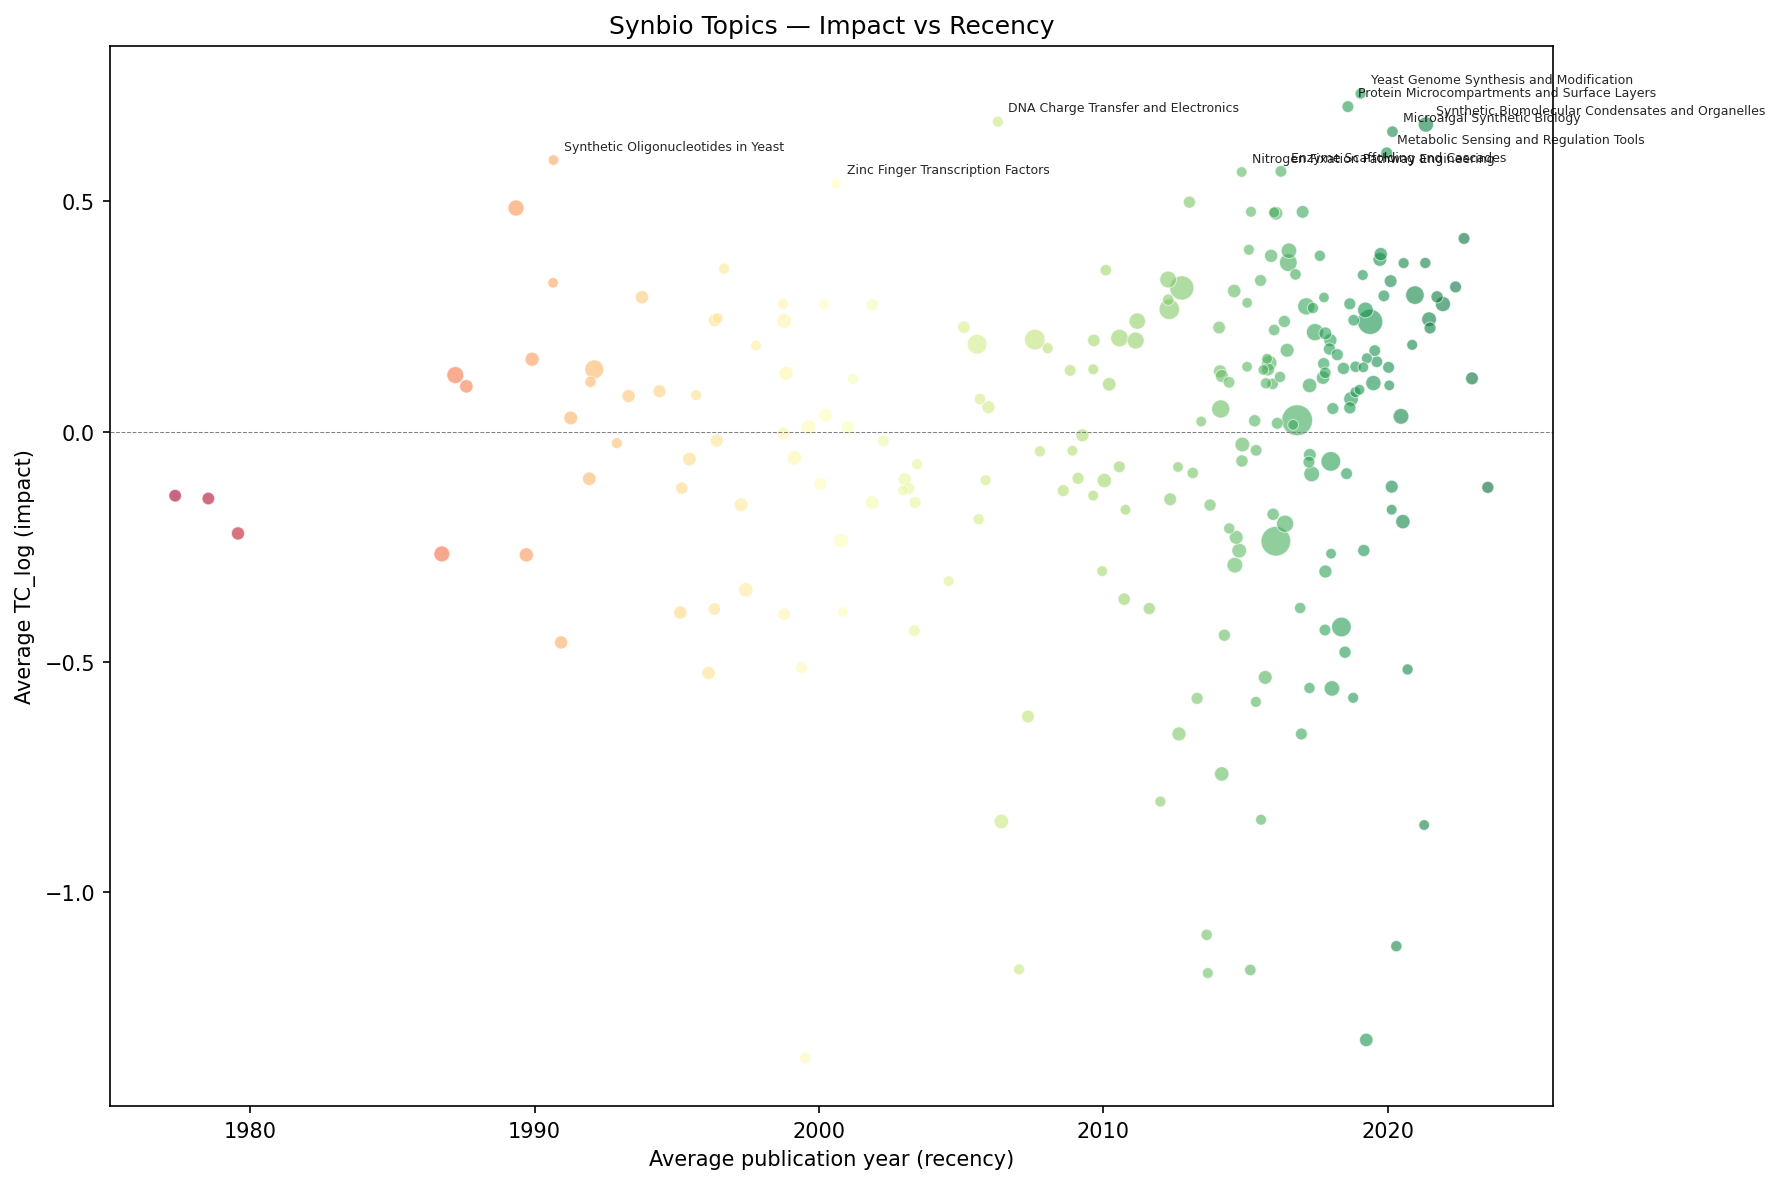

In [14]:
fig, ax = plt.subplots(figsize=(12, 8), dpi=150)

# Size proportional to n_papers (log scale for readability)
sizes = 20 + 200 * (cluster_summary['n_papers'] / cluster_summary['n_papers'].max())

sc = ax.scatter(
    cluster_summary['avg_year'],
    cluster_summary['avg_TC_log'],
    s=sizes,
    alpha=0.6,
    edgecolors='white',
    linewidth=0.5,
    c=cluster_summary['avg_year'],
    cmap='RdYlGn',
)

# Label top-impact and most-recent topics
top_n = 10
for idx in cluster_summary.nlargest(top_n, 'avg_TC_log').index:
    row = cluster_summary.loc[idx]
    ax.annotate(
        row['global_name'],
        (row['avg_year'], row['avg_TC_log']),
        fontsize=6, alpha=0.85,
        textcoords='offset points', xytext=(5, 5),
    )

ax.set_xlabel('Average publication year (recency)')
ax.set_ylabel('Average TC_log (impact)')
ax.set_title('Synbio Topics — Impact vs Recency')
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.show()

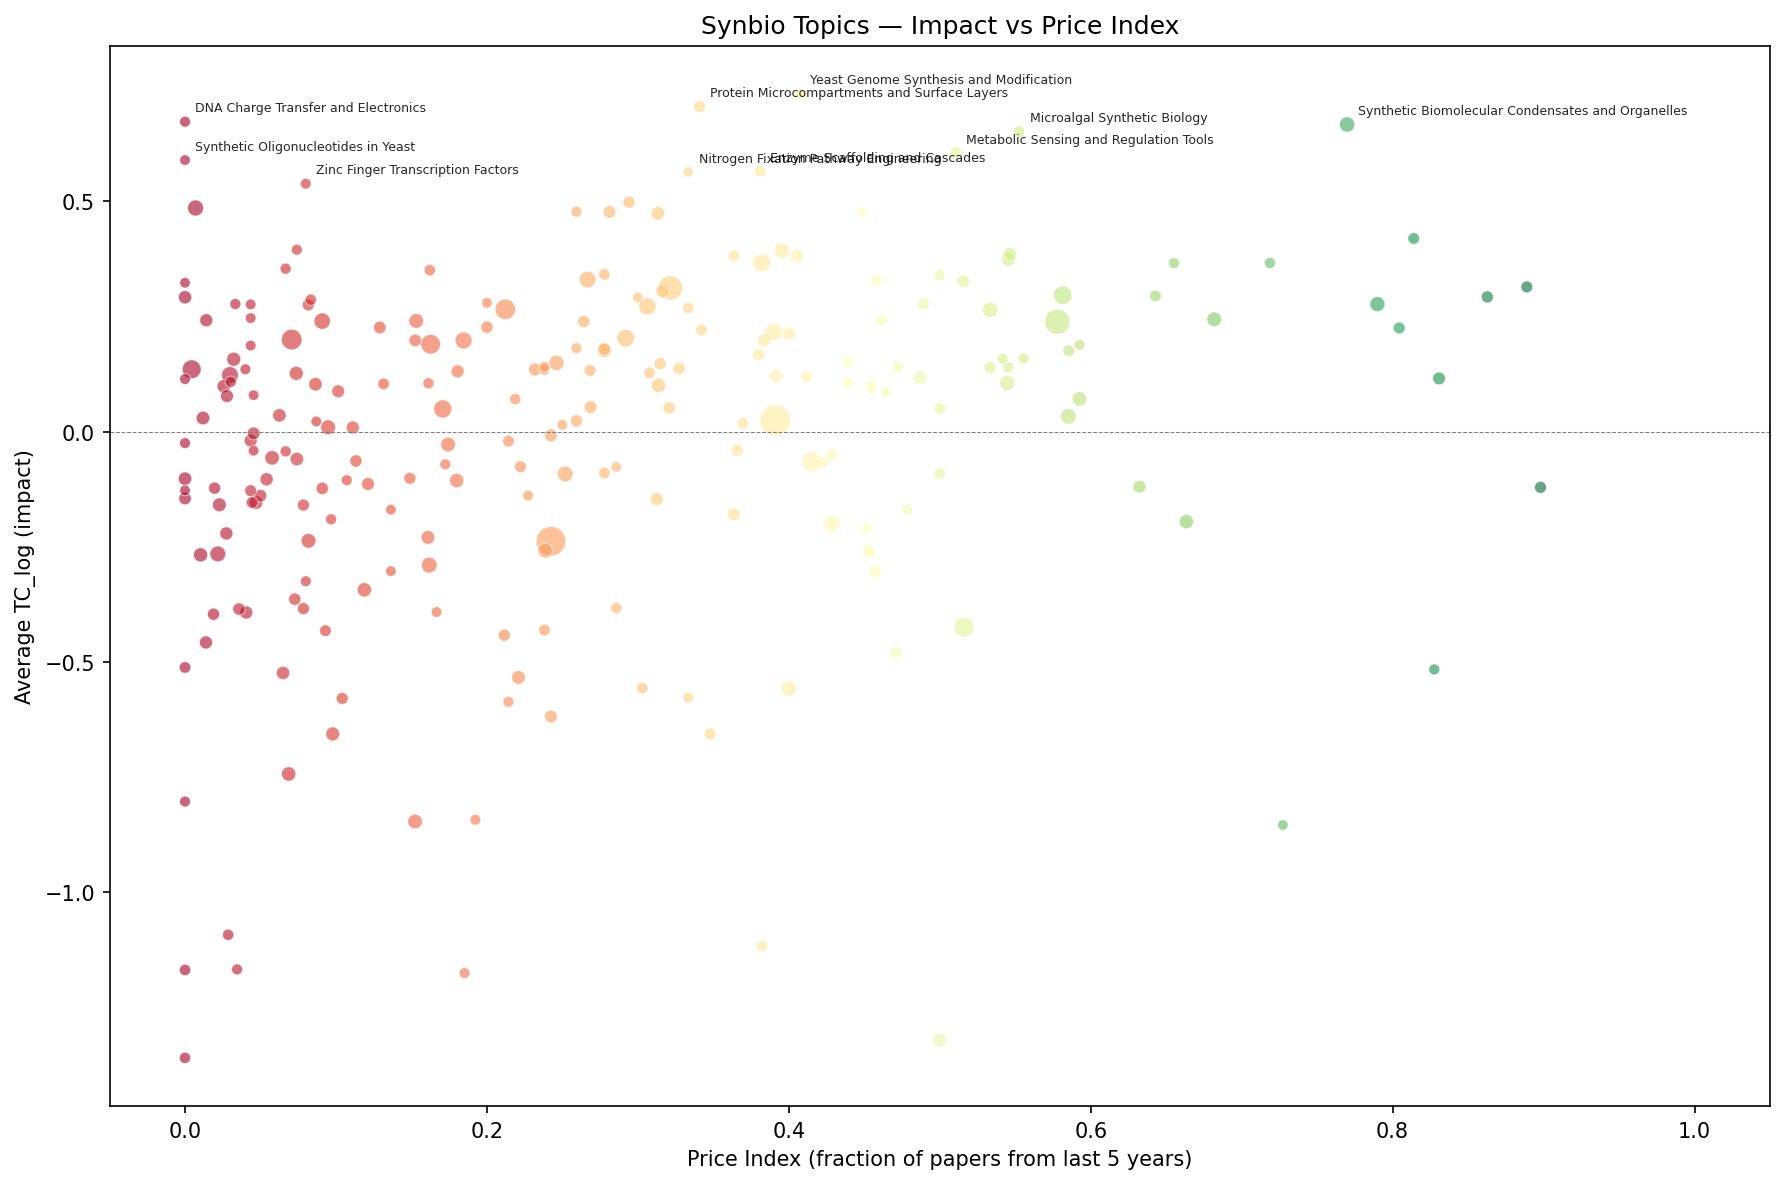

In [15]:
# --- Impact vs Price Index scatterplot ---
fig, ax = plt.subplots(figsize=(12, 8), dpi=150)

sizes = 20 + 200 * (cluster_summary['n_papers'] / cluster_summary['n_papers'].max())

sc = ax.scatter(
    cluster_summary['price_index'],
    cluster_summary['avg_TC_log'],
    s=sizes,
    alpha=0.6,
    edgecolors='white',
    linewidth=0.5,
    c=cluster_summary['price_index'],
    cmap='RdYlGn',
)

# Label top-impact topics
top_n = 10
for idx in cluster_summary.nlargest(top_n, 'avg_TC_log').index:
    row = cluster_summary.loc[idx]
    ax.annotate(
        row['global_name'],
        (row['price_index'], row['avg_TC_log']),
        fontsize=6, alpha=0.85,
        textcoords='offset points', xytext=(5, 5),
    )

ax.set_xlabel('Price Index (fraction of papers from last 5 years)')
ax.set_ylabel('Average TC_log (impact)')
ax.set_title('Synbio Topics — Impact vs Price Index')
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.set_xlim(-0.05, 1.05)
plt.tight_layout()
plt.show()

## Topic model plot — Papers
Scatter plot of all papers in 2D UMAP space, colored by topic cluster. We compute a 2D UMAP projection from the original 384-dim embeddings (same `cosine` metric and seed as the topic model).

In [16]:
# Load embeddings — row-aligned with doc_topics
papers_emb = np.load(os.path.join(EMBEDS, 'papers_embeddings.npy'))
print(f"Embeddings shape: {papers_emb.shape}")
print(f"Doc-topics rows: {len(doc_topics):,}")
assert len(papers_emb) == len(doc_topics), "Embeddings and doc_topics must be aligned"

Embeddings shape: (33625, 384)
Doc-topics rows: 33,625


In [17]:
# 2D UMAP projection for visualization
umap_2d = UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=SEED,
)
papers_xy = umap_2d.fit_transform(papers_emb)
print(f"2D projection shape: {papers_xy.shape}")

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


2D projection shape: (33625, 2)


In [18]:
# Build a plotting dataframe
df_plot = doc_topics.copy()
df_plot['x'] = papers_xy[:, 0]
df_plot['y'] = papers_xy[:, 1]
df_plot = df_plot.merge(topic_names[['topic', 'global_name']], on='topic', how='left')

# Merge in citations for point sizing
df_plot = df_plot.merge(
    papers[['id', 'cited_by_count']].drop_duplicates('id'),
    on='id', how='left',
)

# Assign colors: one color per topic, outliers (-1) in light grey
unique_topics = sorted(df_plot.loc[df_plot['topic'] >= 0, 'topic'].unique())
palette = [
    "#f00f15", "#2270e7", "#e5e510", "#ff8103", "#4f3dd1",
    "#26cc3a", "#ec058e", "#9cb8c2", "#fffdd0", "#b40e68",
    "#5afb5a", "#beaed4", "#fdc086", "#99fdff", "#c430ff",
    "#e4dbe0", "#bf5b17", "#666666",
]
color_cycle = cycle(palette)
topic_color = {t: next(color_cycle) for t in unique_topics}
topic_color[-1] = '#d3d3d3'  # outliers
df_plot['color'] = df_plot['topic'].map(topic_color)

print(f"Plotting {len(df_plot):,} points ({len(unique_topics)} topics + outliers)")
df_plot.head(3)

Plotting 33,625 points (234 topics + outliers)


,id,topic,x,y,global_name,cited_by_count,color
0,https://openalex.org/W2047366876,4,2.911017,-0.715761,Synthetic DNA Motifs for Immune Activation,3532,#4f3dd1
1,https://openalex.org/W2072812562,65,-0.332041,2.596985,rRNA and Phylogenetics Analysis,3046,#beaed4
2,https://openalex.org/W1567090568,64,-3.103004,1.984273,DNA Nanostructure Design and Assembly,2848,#5afb5a


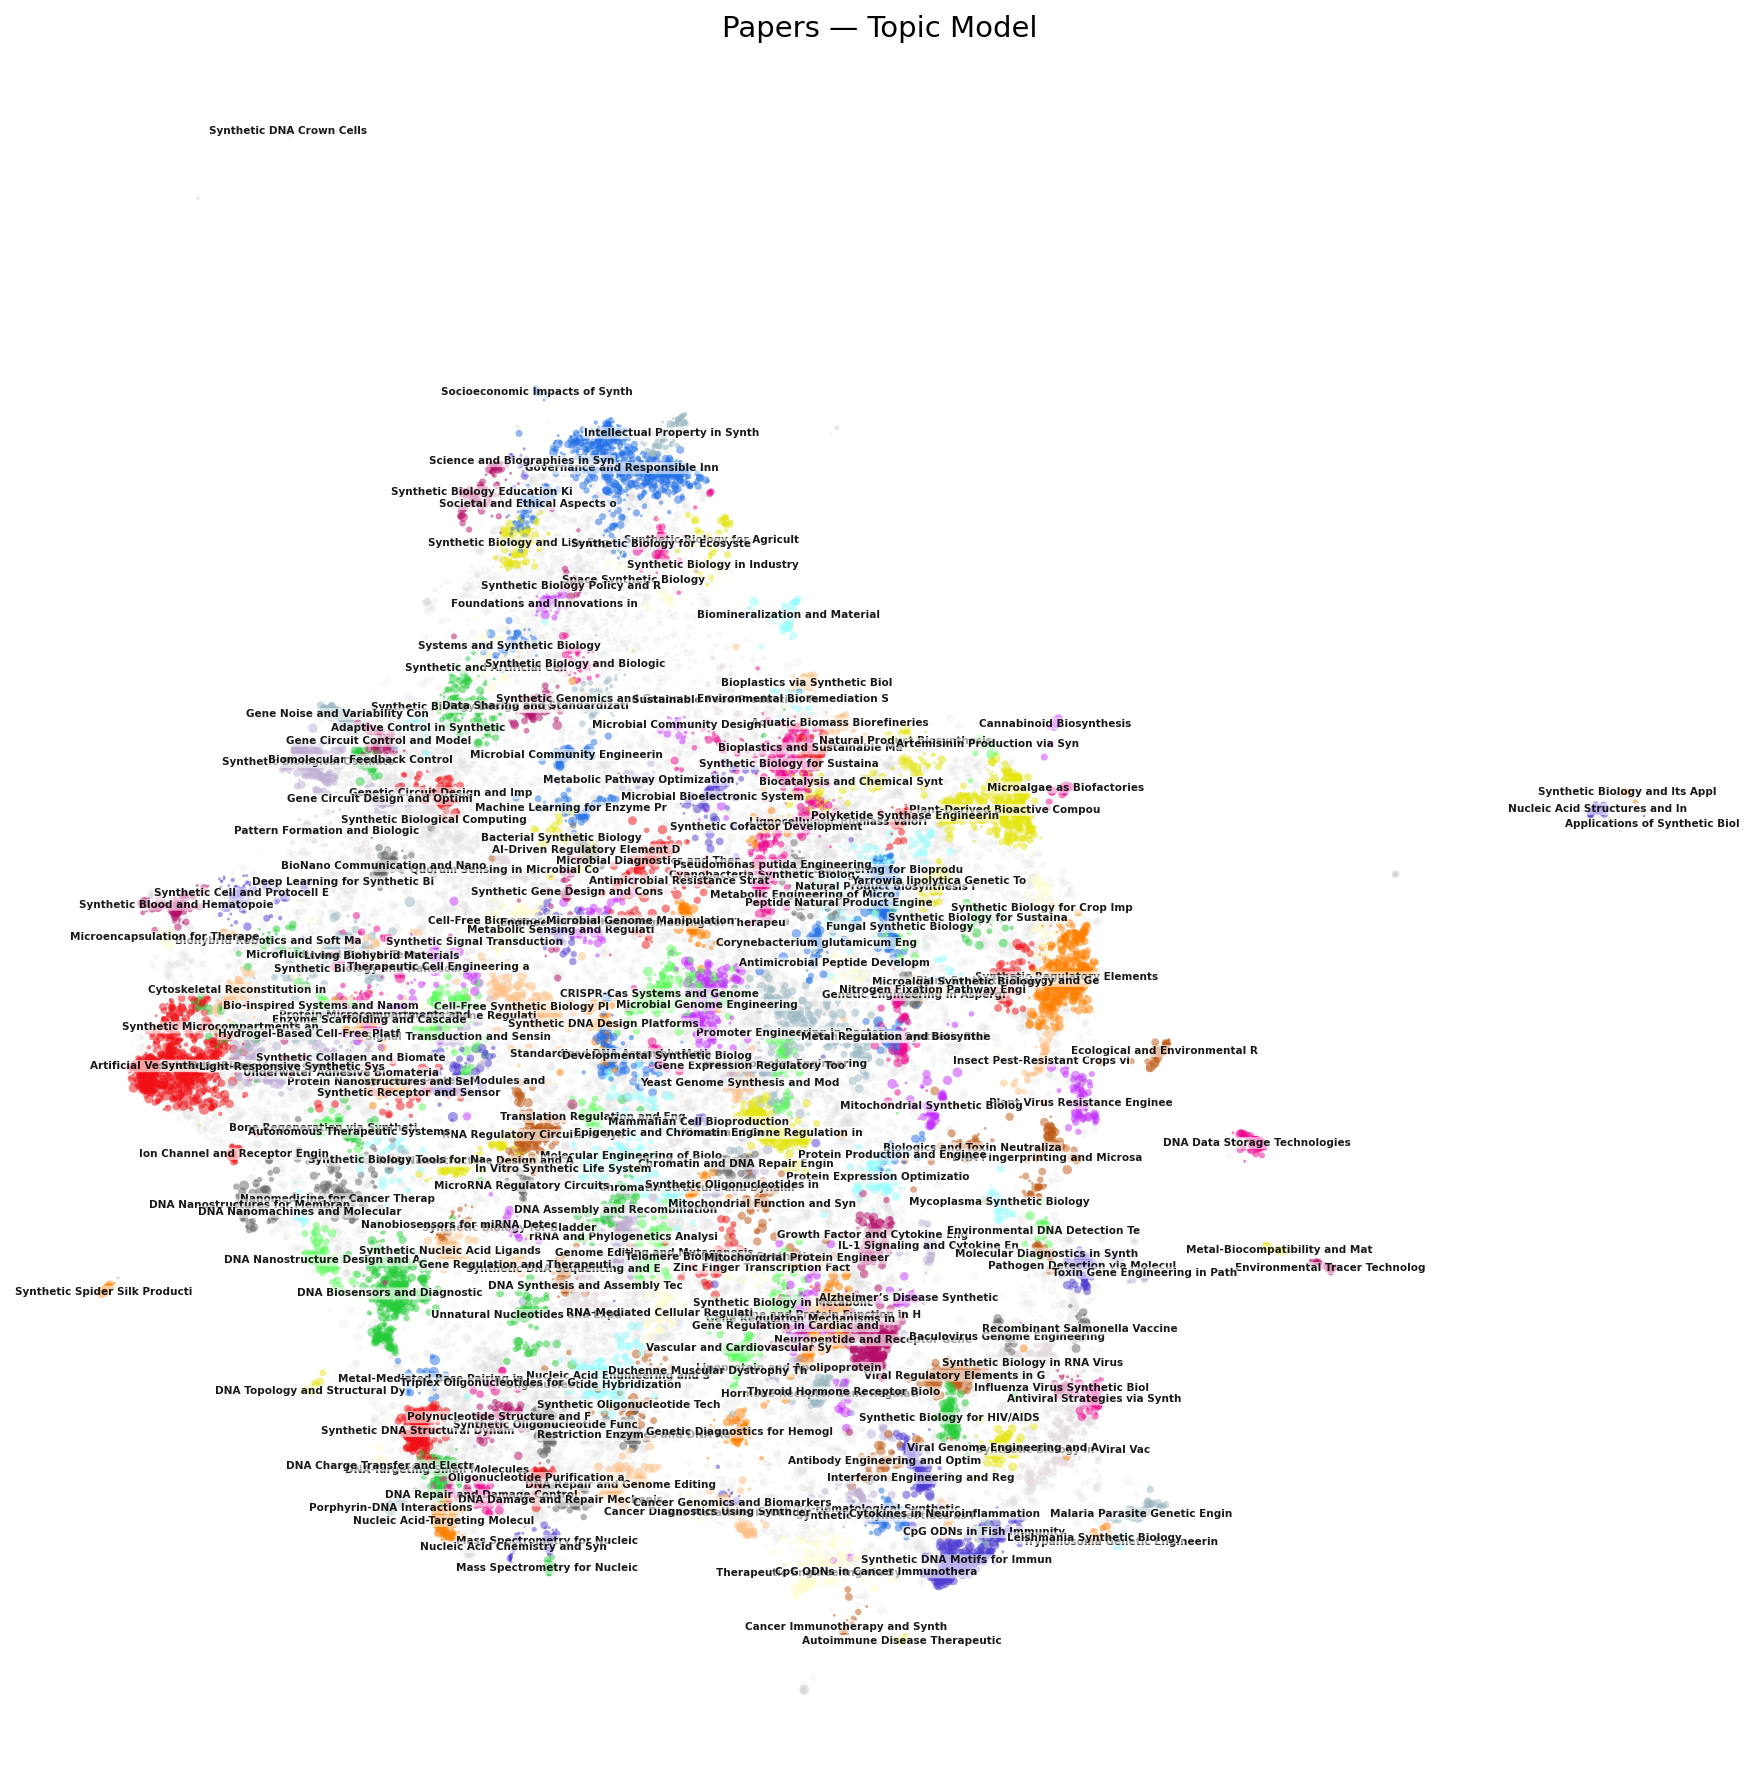

In [19]:
# --- Papers topic model scatter plot ---
fig, ax = plt.subplots(figsize=(12, 12), dpi=150)

# Point sizes from citations (log-scaled)
citations = df_plot['cited_by_count'].fillna(0).clip(lower=0)
max_c = citations.max()
if max_c > 0:
    sizes = 2 + 30 * (np.log1p(citations) / np.log1p(max_c))
else:
    sizes = np.full(len(df_plot), 2)

# Draw outliers first (underneath), then real topics on top
outlier_mask = df_plot['topic'] == -1
ax.scatter(df_plot.loc[outlier_mask, 'x'], df_plot.loc[outlier_mask, 'y'],
           c='#d3d3d3', s=sizes[outlier_mask], alpha=0.15, edgecolors='none')
ax.scatter(df_plot.loc[~outlier_mask, 'x'], df_plot.loc[~outlier_mask, 'y'],
           c=df_plot.loc[~outlier_mask, 'color'], s=sizes[~outlier_mask],
           alpha=0.5, edgecolors='none')

# Cluster labels at median position
for t in unique_topics:
    mask = df_plot['topic'] == t
    n = mask.sum()
    if n < 20:
        continue
    x_c = df_plot.loc[mask, 'x'].median()
    y_c = df_plot.loc[mask, 'y'].median()
    name = df_plot.loc[mask, 'global_name'].iloc[0]
    label = str(name)[:30] if pd.notna(name) else str(t)
    ax.text(x_c, y_c, label, fontsize=5, fontweight='bold',
            ha='center', va='center', alpha=0.9, color='black',
            bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.6, ec='none'))

ax.set_title('Papers — Topic Model', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()